In [1]:
from pathlib import Path
import xarray as xr
import torch
import torch.nn.functional
from climanet.st_encoder_decoder import SpatioTemporalModel
from climanet.utils import set_seed, configure_compute_resources, plot_results, plot_histograms, plot_loss
from climanet.train import train_monthly_model, TrainConfig
from climanet.predict import predict_monthly_var, PredictionConfig
from climanet.dataset import DatasetConfig, DataLoaderConfig

from torch.utils.data import random_split
from tbparse import SummaryReader
import matplotlib.pyplot as plt

## Read data

In [3]:
# without diurnal cycle
data_folder = Path("./eso4clima/dc_data")
run_dir = "./runs_daily"

var_name = "tos"

# 1 month train, 1 month validation and test
daily_data = xr.open_mfdataset(data_folder / f"202101_day_ERA5dc_masked_{var_name}.nc")
daily_data_validation = xr.open_mfdataset(data_folder / f"202102_day_ERA5dc_masked_{var_name}.nc")
daily_data_test = xr.open_mfdataset(data_folder / f"202103_day_ERA5dc_masked_{var_name}.nc")

monthly_data = xr.open_mfdataset(data_folder / f"202101_mon_ERA5dc_full_{var_name}.nc")
monthly_data_validation = xr.open_mfdataset(data_folder / f"202102_mon_ERA5dc_full_{var_name}.nc")
monthly_data_test = xr.open_mfdataset(data_folder / f"202103_mon_ERA5dc_full_{var_name}.nc")

file_name = data_folder / "era5_lsm_bool.nc"  # downloded from era5 and regridded using the function `regrid_to_boundary_centered_grid`
lsm_mask = xr.open_dataset(file_name)
# lsm_mask = lsm_mask.rename({'latitude': 'lat', 'longitude': 'lon'})

## Subset data (for fast example)

In [4]:
# coordinates of subset
lon_subset = slice(-50, 50)  # one lon -179.9 is nan, check data
lat_subset = slice(-30, 10)

daily_subset = daily_data.sel(lon=lon_subset, lat=lat_subset)
monthly_subset = monthly_data.sel(lon=lon_subset, lat=lat_subset)
lsm_subset = lsm_mask.sel(lon=lon_subset, lat=lat_subset)  # True=Land

daily_validation_subset = daily_data_validation.sel(lon=lon_subset, lat=lat_subset)
monthly_validation_subset = monthly_data_validation.sel(lon=lon_subset, lat=lat_subset)

daily_test_subset = daily_data_test.sel(lon=lon_subset, lat=lat_subset)
monthly_test_subset = monthly_data_test.sel(lon=lon_subset, lat=lat_subset)

print(daily_subset[var_name].shape, monthly_subset[var_name].shape)  # (time, lat, lon)

(31, 160, 400) (1, 160, 400)


## Train the model

In [5]:
# create the model (small)
set_seed()

In [6]:
patch_size = (1, 4, 4)
model = SpatioTemporalModel(patch_size=patch_size, overlap=2, embed_dim=64, dropout=0.2, hidden=64)

In [7]:
# Device and resources
device = "cpu"
compute_threads = 4
dataloader_num_workers = 2
model = configure_compute_resources(model, device=device, compute_threads=compute_threads, dataloader_num_workers=dataloader_num_workers)

In [8]:
# create dataset config
num_patches = (10, 10)
spatial_patch_size = (patch_size[1]*num_patches[0], patch_size[2]*num_patches[1])
stride = (spatial_patch_size[0] // 5, spatial_patch_size[1] // 5)

dataset_config = DatasetConfig(
    is_hourly=False,
    var_name="tos",
    spatial_dims=("lat", "lon"),
    patch_size=(1, *spatial_patch_size),
    stride=stride,
    sh_pos_table=None,
    sh_embed_dim=96,
    sh_order_L=10,   
    verbose=False,
)
dataset_config

DatasetConfig(is_hourly=False, var_name='tos', spatial_dims=('lat', 'lon'), patch_size=(1, 40, 40), stride=(8, 8), sh_pos_table=None, sh_embed_dim=96, sh_order_L=10, verbose=False)

In [9]:
# create dataloader config
dataloader_config = DataLoaderConfig(
    batch_size=10,
    shuffle=True,
    num_workers= dataloader_num_workers,
    pin_memory=False,
    persistent_workers=False,
    device=device,
)
dataloader_config

DataLoaderConfig(batch_size=10, shuffle=True, num_workers=2, pin_memory=False, persistent_workers=False, device='cpu')

In [10]:
# create training config
training_config = TrainConfig(
    calculate_residuals=True,
    num_epoch=100,
    patience=10,
    accumulation_steps=2,
    optimizer_lr=1e-3,
    device=device,
    verbose=True,
    verbose_epoch_interval=20,
    tune_checkpoint=False,
    store_model=True,
)
training_config

TrainConfig(calculate_residuals=True, num_epoch=100, patience=10, accumulation_steps=2, optimizer_lr=0.001, device='cpu', verbose=True, verbose_epoch_interval=20, tune_checkpoint=False, store_model=True)

### Start training loop

In [11]:
%%time
# verbose is True
trained_model = train_monthly_model(
    model=model,
    input_data_train=daily_subset,
    monthly_data_train=monthly_subset,
    dataloader_config=dataloader_config,
    dataset_config=dataset_config,
    training_config=training_config,
    input_data_validation=daily_validation_subset,
    monthly_data_validation=monthly_validation_subset,
    land_mask=lsm_subset["lsm"],
    run_dir=run_dir,
)

/home/sarah/miniconda3/envs/eso4clima/lib/python3.11/site-packages/ray/train/_internal/session.py:683: UserWarning: `get_checkpoint` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


Epoch 0: gap between train and val loss: -0.039107
Epoch 0: best_loss = 0.022844
Epoch 20: gap between train and val loss: 0.004125
Epoch 20: best_loss = 0.021400
Epoch 40: gap between train and val loss: 0.005026
Epoch 40: best_loss = 0.021400
Epoch 60: gap between train and val loss: 0.005210
Epoch 60: best_loss = 0.021400
Epoch 80: gap between train and val loss: 0.005347
Epoch 80: best_loss = 0.021400
Training complete. Best loss: 0.021400
Model saved to runs_daily/best_model.pth
CPU times: user 1h 33min 53s, sys: 2min 5s, total: 1h 35min 58s
Wall time: 26min 10s


## Inspect results and compare

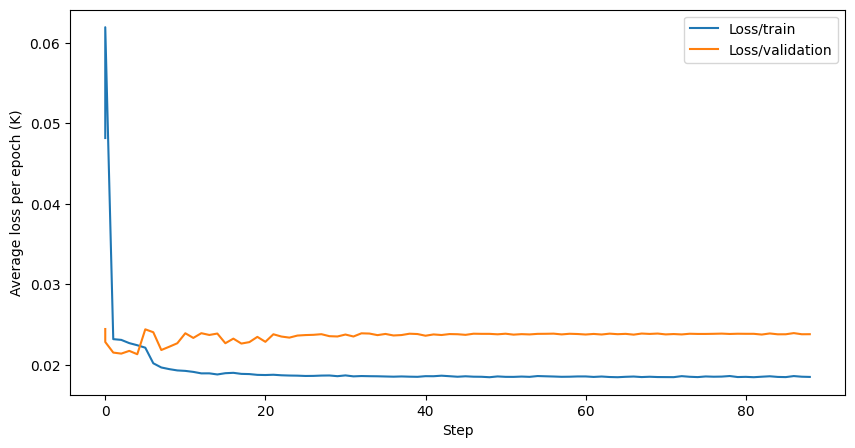

In [12]:
plot_loss(run_dir, list_loss_var=["Loss/train", "Loss/validation"], unit="K")

In [11]:
# create prediction config
prediction_config = PredictionConfig(
    calculate_residuals=True,
    return_numpy=True,
    save_predictions=True,
    return_loss=False,
    device=device,
    verbose=True,
)

In [12]:
# inference on test data, verbose is True
predictions = predict_monthly_var(
    model=f"{run_dir}/best_model.pth",
    input_data=daily_test_subset, 
    monthly_data=monthly_test_subset, 
    dataset_config=dataset_config,
    dataloader_config=dataloader_config,
    prediction_config=prediction_config,
    land_mask=lsm_subset["lsm"],
    run_dir=run_dir,
)

Processed batch 74, with average loss: 0.0305
Predictions saved to './runs_daily'
Average loss over all batches: 0.0305


In [14]:
predictions_res = xr.open_dataset(f"{run_dir}/202103_predictions.nc")

In [15]:
# add to monthly average
input_data_averaged = daily_test_subset.resample({"time": "MS"}).mean(skipna=True)
input_data_averaged["time"] = monthly_test_subset["time"]
predictions = input_data_averaged[var_name] + predictions_res[var_name]

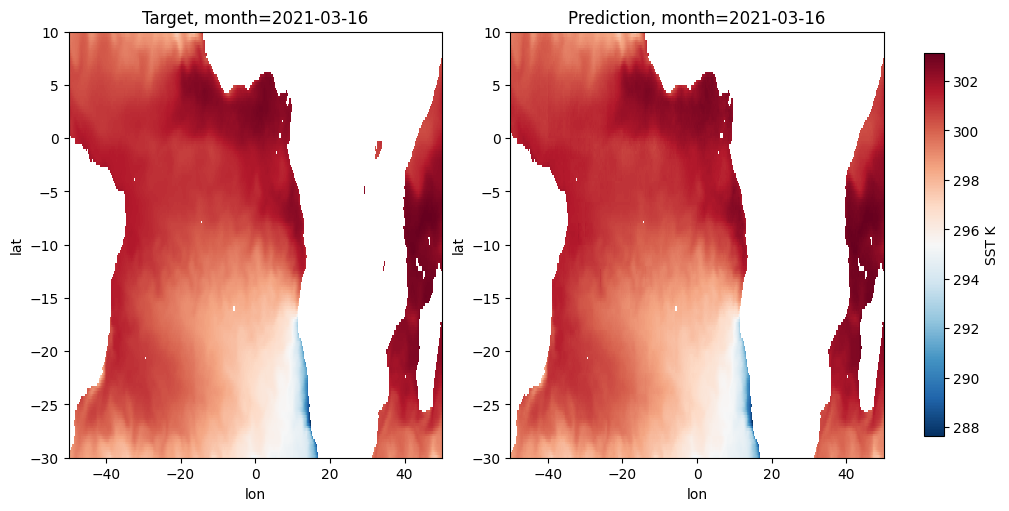

In [16]:
ocean = ~lsm_subset["lsm"].values
masked_target = monthly_test_subset[var_name].where(ocean)
masked_pred = predictions.where(ocean)
plot_results(masked_target, masked_pred, label="SST K", title=("Target", "Prediction"))

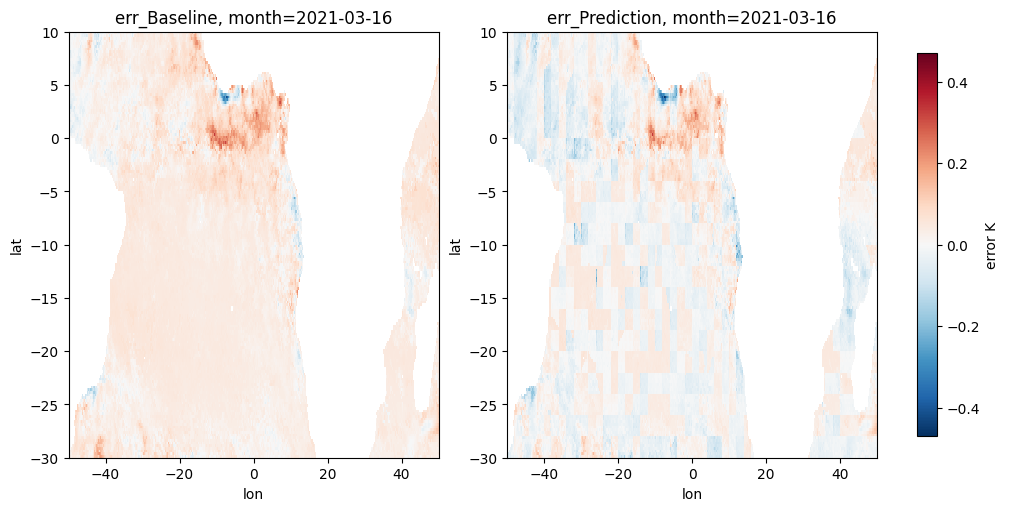

In [18]:
err_baseline = (monthly_test_subset[var_name] - input_data_averaged[var_name])   # M - mean(D)
err_predictions = (monthly_test_subset[var_name] - predictions)  # M - M_hat

ocean = ~lsm_subset["lsm"].values
masked_err_baseline = err_baseline.where(ocean)
masked_err_predictions = err_predictions.where(ocean) 

plot_results(masked_err_baseline, masked_err_predictions, label="error K", title=("err_Baseline", "err_Prediction"), error=True)

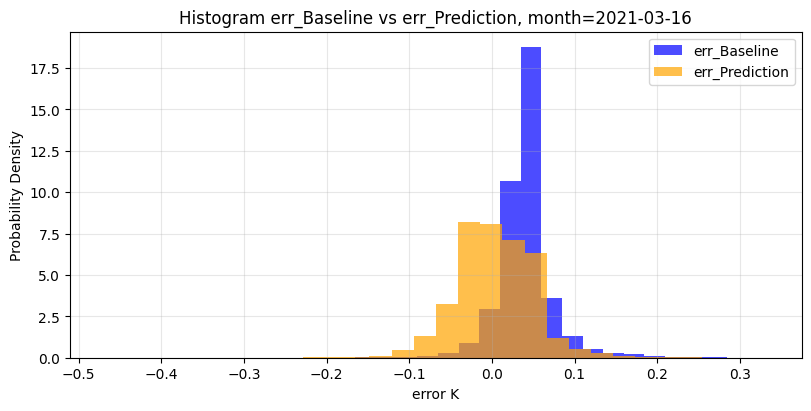

In [19]:
plot_histograms(masked_err_baseline, masked_err_predictions, label="error K", legend_labels=("err_Baseline", "err_Prediction"))